# OpenTH quickstart

A short tour of OpenTH in a notebook: a **steady** pipeline, a **transient** run with a plot, the **component/connection** API, and the **paper benchmarks**.

Install into the project venv first:

```bash
pip install -e ".[dev,notebook]"   # adds jupyterlab + matplotlib
jupyter lab
```

In [1]:
import sys, pathlib

# Import openth. If it isn't installed, fall back to the repo's src/ directory
# (works whether the notebook is launched from the repo root or examples/).
try:
    import openth  # noqa: F401
except ModuleNotFoundError:
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "openth").is_dir():
            sys.path.insert(0, str(base / "src"))
            break

import openth as th
print("OpenTH", th.__version__)

OpenTH 0.0.1


## 1. Steady state

A 100 m helium pipeline: fix the outlet pressure and the inlet mass flow, then solve for the
steady state. `add_pipe(..., n_cells=20)` subdivides it into 20 finite-volume cells.

In [2]:
model = th.Model(fluid=th.Fluid("helium"))
model.add_pipe("inlet", "outlet", length=100, diameter=0.5, n_cells=20)
model.pressure_boundary("outlet", p=200e3, T=300)
model.mass_flow_boundary("inlet", mdot=30, T=300)

result = model.steady_state(relaxation=0.5, max_outer_iterations=600)
print("converged:", result.converged, "in", result.iterations, "iterations")
print(f"inlet pressure : {model.pressure('inlet')/1e3:.1f} kPa")
print(f"mass flow      : {model.flow_through('inlet->outlet'):.3f} kg/s")

converged: True in 70 iterations
inlet pressure : 336.7 kPa
mass flow      : 30.000 kg/s


## 2. Transient + plot — adiabatic vessel blow-down

A sealed vessel (a node with a `volume`) discharges through a throttle to a lower
pressure. With the **energy equation on and no heat added** (adiabatic), the gas left in
the vessel expands and **cools** — its temperature is *not* held fixed. (Holding it fixed
would be *isothermal*, which physically needs the walls to feed heat in.) We start from
the charged state with `steady_init=False`, so the vessel pressure and temperature are
released at t=0 and evolve. The final temperature follows the adiabatic relation
$T/T_0 = (p/p_0)^{(\gamma-1)/\gamma}$.

We record the vessel pressure and temperature plus the **mass flow** through the throttle,
and derive the **volume flow** $Q = \dot m / \rho$ at the vessel.

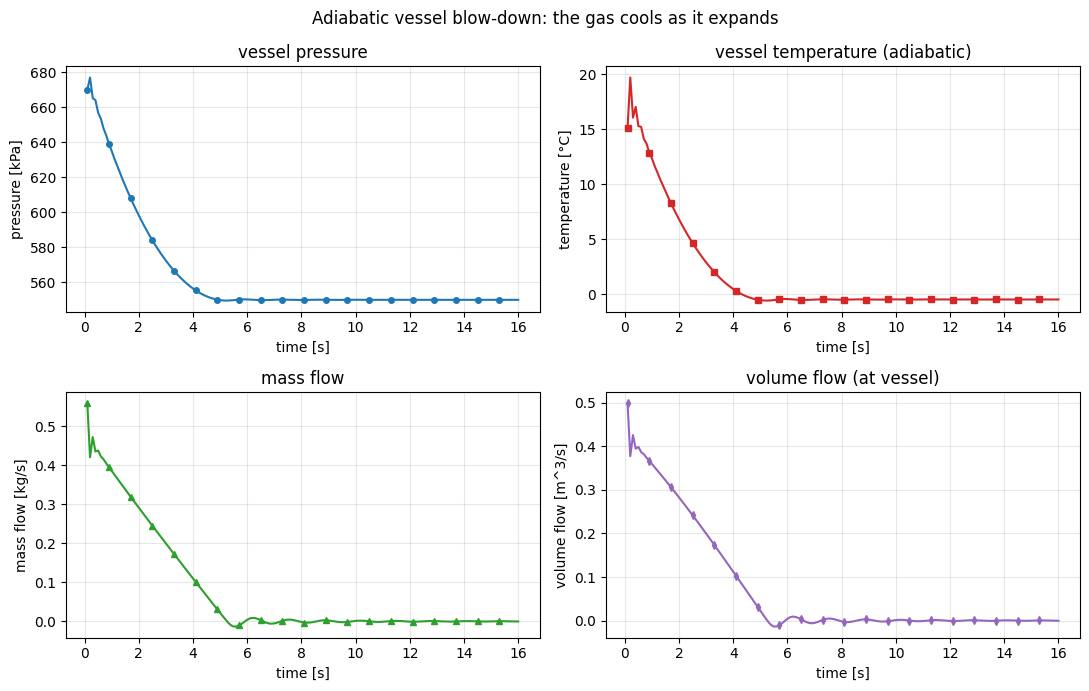

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

he = th.Fluid("helium")
m = th.Model(fluid=he)
m.add_pipe("tank", "out", length=10.0, diameter=0.05, n_cells=2, name="throttle")
tank = m.node("tank")
tank.volume = 8.0          # m^3 vessel
tank.state.p0 = 700e3      # charged to 700 kPa / 300 K
tank.state.T = 300.0
m.pressure_boundary("out", p=550e3, T=300.0)   # discharge to 550 kPa

# Adiabatic (solve_energy=True, no heat source), released from the charged state.
hist = m.run(dt=0.1, duration=16.0, record=("p:tank", "T:tank", "flow:throttle"),
             alpha=0.6, relaxation=0.4, solve_energy=True, steady_init=False)
t = hist["t"]
mdot = hist["flow:throttle"]                                   # mass flow [kg/s]
vdot = [md / he.density(p, T)                                  # volume flow [m^3/s]
        for md, p, T in zip(mdot, hist["p:tank"], hist["T:tank"])]

fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0, 0].plot(t, [p / 1e3 for p in hist["p:tank"]], marker="o", markevery=8, ms=4)
ax[0, 0].set(xlabel="time [s]", ylabel="pressure [kPa]", title="vessel pressure")
ax[0, 1].plot(t, [T - 273.15 for T in hist["T:tank"]], marker="s", markevery=8, ms=4, color="C3")
ax[0, 1].set(xlabel="time [s]", ylabel="temperature [°C]", title="vessel temperature (adiabatic)")
ax[1, 0].plot(t, mdot, marker="^", markevery=8, ms=4, color="C2")
ax[1, 0].set(xlabel="time [s]", ylabel="mass flow [kg/s]", title="mass flow")
ax[1, 1].plot(t, vdot, marker="d", markevery=8, ms=4, color="C4")
ax[1, 1].set(xlabel="time [s]", ylabel="volume flow [m^3/s]", title="volume flow (at vessel)")
for a in ax.flat:
    a.grid(True, alpha=0.3)
fig.suptitle("Adiabatic vessel blow-down: the gas cools as it expands")
fig.tight_layout()
plt.show()

## 3. Component / connection style (`th.Circuit`)

For loops and networks it can be tidier to build from component objects and join their
`.inlet` / `.outlet` ports. Here a blower drives a closed helium loop.

In [4]:
c = th.Circuit(fluid=th.Fluid("helium"))
blower = c.add(th.Pump(head_shutoff=120e3, curve=300.0))
hot  = c.add(th.Pipe(length=15, diameter=0.3, n_cells=6))
cold = c.add(th.Pipe(length=15, diameter=0.3, n_cells=6))

c.connect(blower.outlet, hot.inlet)
c.connect(hot.outlet, cold.inlet)
c.connect(cold.outlet, blower.inlet)
c.pressure_boundary(blower.inlet, p=300e3, T=300)   # closed loop: pin a reference pressure

c.solve_steady_state(relaxation=0.6)
print(f"loop mass flow : {c.flow(blower):.3f} kg/s")
print(f"blower rise    : {(c.pressure(blower.outlet) - c.pressure(blower.inlet))/1e3:+.1f} kPa")

loop mass flow : 12.641 kg/s
blower rise    : +72.1 kPa


## 4. The paper's benchmarks

`openth.benchmarks` builds and runs Greyvenstein's four Section 5 test cases (also available
from the command line as `openth benchmark <name>`).

In [5]:
from openth import benchmarks

for name in benchmarks.BENCHMARKS:
    print(name, "->", benchmarks.run(name))

steady_pipeline -> {'converged': True, 'mdot [kg/s]': 19.2695, 'P1/P2 (PCIM)': 1.2953, 'P1/P2 (exact)': 1.2953}


valve_closure -> {'pre-closure p_valve [kPa]': 698.4, 'peak p_valve [kPa]': 766.2, 'min p_valve [kPa]': 644.7, 'water hammer': True}


branching_network -> {'p_A initial [kPa]': 681.7, 'p_A peak [kPa]': 792.9, 'p_A min [kPa]': 629.8, 'steps': 333}


blowdown -> {'initial mdot [kg/s]': 1.7071, 'final mdot [kg/s]': 0.0538, 'monotonic decay': True, 'steps': 175}
